In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

csv_filename = "/home/eduardo/Área de trabalho/Ciencia_De_Dados/data/anilist_genres_years.csv"

df = pd.read_csv(csv_filename)

df_cleaned = df.dropna()
df_cleaned.head()

,Title,Genres,Score,Popularity,Year
0,Fate/stay night [Heaven's Feel] III. spring song,"Action, Drama, Fantasy, Psychological, Superna...",85.0,95007,2020
1,Hatena☆Illusion,"Comedy, Romance, Supernatural",50.0,12861,2020
2,Entotsu-machi no Poupelle,Fantasy,59.0,2787,2020
4,22/7,"Drama, Music",64.0,17354,2020
5,Made in Abyss: Fukaki Tamashii no Reimei,"Action, Adventure, Drama, Fantasy, Horror, Mys...",85.0,130668,2020


In [10]:
df_cleaned['Year'].value_counts()

Year
2021    244
2023    244
2020    241
2022    241
2024    239
Name: count, dtype: int64

In [ ]:
df_cleaned = df_cleaned.copy()

df_cleaned.loc[:, 'Popularity'] = pd.to_numeric(df_cleaned['Popularity'], errors='coerce')
df_cleaned = df_cleaned.assign(Genres=df_cleaned['Genres'].str.split(', ')).explode('Genres').copy()

most_popular_by_genre_year = df_cleaned.loc[df_cleaned.groupby(['Year', 'Genres'])['Popularity'].idxmax()].copy()

high_score_animes = df_cleaned
high_score_animes['Score'] = pd.to_numeric(high_score_animes['Score'])  
high_score_animes[high_score_animes['Score'] > 80]

,Title,Genres,Score,Popularity,Year
0,Fate/stay night [Heaven's Feel] III. spring song,Action,85.0,95007,2020
0,Fate/stay night [Heaven's Feel] III. spring song,Drama,85.0,95007,2020
0,Fate/stay night [Heaven's Feel] III. spring song,Fantasy,85.0,95007,2020
0,Fate/stay night [Heaven's Feel] III. spring song,Psychological,85.0,95007,2020
0,Fate/stay night [Heaven's Feel] III. spring song,Supernatural,85.0,95007,2020
...,...,...,...,...,...
1228,Make Heroine ga Oosugiru!,Comedy,81.0,75497,2024
1228,Make Heroine ga Oosugiru!,Romance,81.0,75497,2024
1246,Uma Musume: Pretty Derby - Shin Jidai no Tobira,Drama,87.0,5419,2024
1246,Uma Musume: Pretty Derby - Shin Jidai no Tobira,Slice of Life,87.0,5419,2024


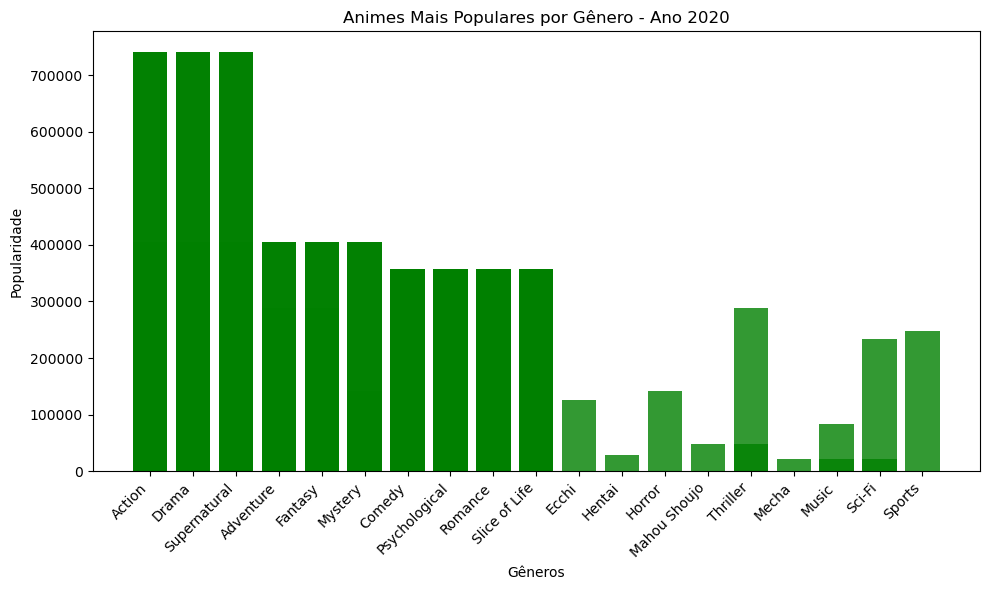

In [ ]:
yearly_data_2020 = most_popular_by_genre_year[most_popular_by_genre_year['Year'] == 2020]

plt.figure(figsize=(10, 6))
plt.bar(
    yearly_data_2020['Genres'], 
    yearly_data_2020['Popularity'], 
    color='green', 
    alpha=0.8
)
plt.title('Animes Mais Populares por Gênero - Ano 2020')
plt.xlabel('Gêneros')
plt.ylabel('Popularidade')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()


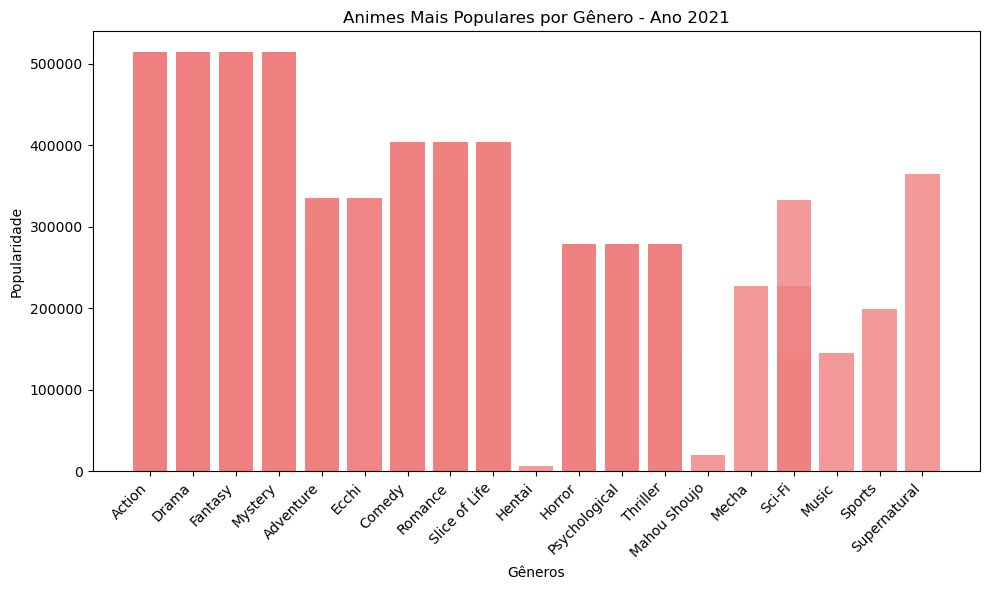

In [ ]:
yearly_data_2021 = most_popular_by_genre_year[most_popular_by_genre_year['Year'] == 2021]

plt.figure(figsize=(10, 6))
plt.bar(
    yearly_data_2021['Genres'], 
    yearly_data_2021['Popularity'], 
    color='lightcoral', 
    alpha=0.8
)
plt.title('Animes Mais Populares por Gênero - Ano 2021')
plt.xlabel('Gêneros')
plt.ylabel('Popularidade')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()


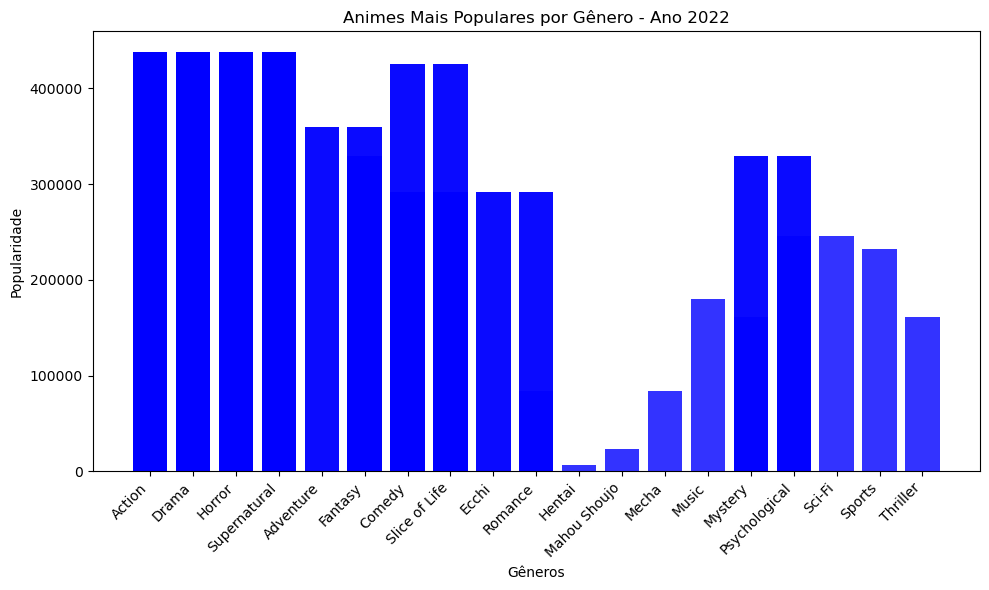

In [ ]:
yearly_data_2022 = most_popular_by_genre_year[most_popular_by_genre_year['Year'] == 2022]

plt.figure(figsize=(10, 6))
plt.bar(
    yearly_data_2022['Genres'], 
    yearly_data_2022['Popularity'], 
    color='blue', 
    alpha=0.8
)
plt.title('Animes Mais Populares por Gênero - Ano 2022')
plt.xlabel('Gêneros')
plt.ylabel('Popularidade')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()


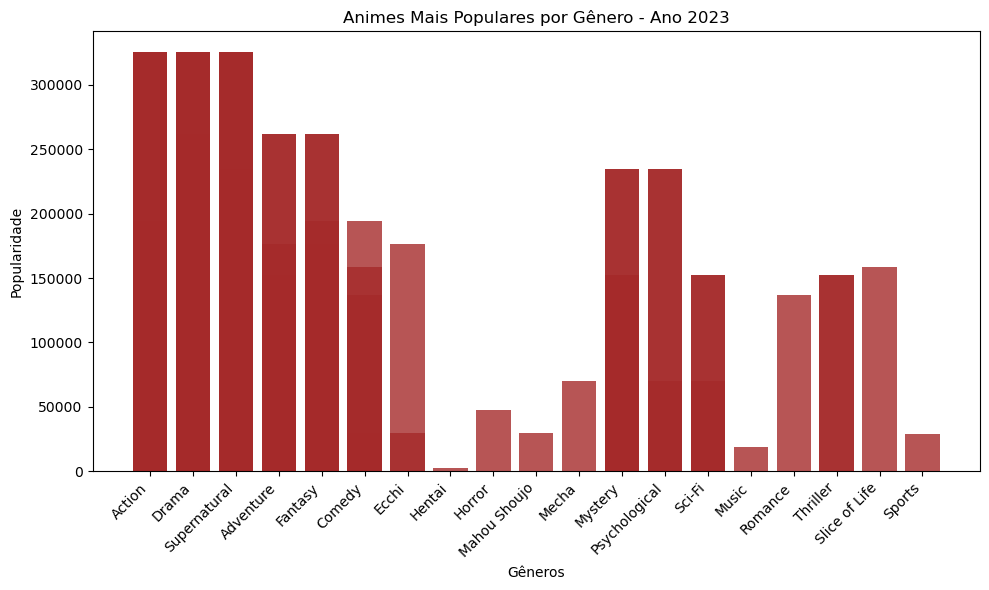

In [ ]:
yearly_data_2023 = most_popular_by_genre_year[most_popular_by_genre_year['Year'] == 2023]

plt.figure(figsize=(10, 6))
plt.bar(
    yearly_data_2023['Genres'], 
    yearly_data_2023['Popularity'], 
    color='brown', 
    alpha=0.8
)
plt.title('Animes Mais Populares por Gênero - Ano 2023')
plt.xlabel('Gêneros')
plt.ylabel('Popularidade')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()


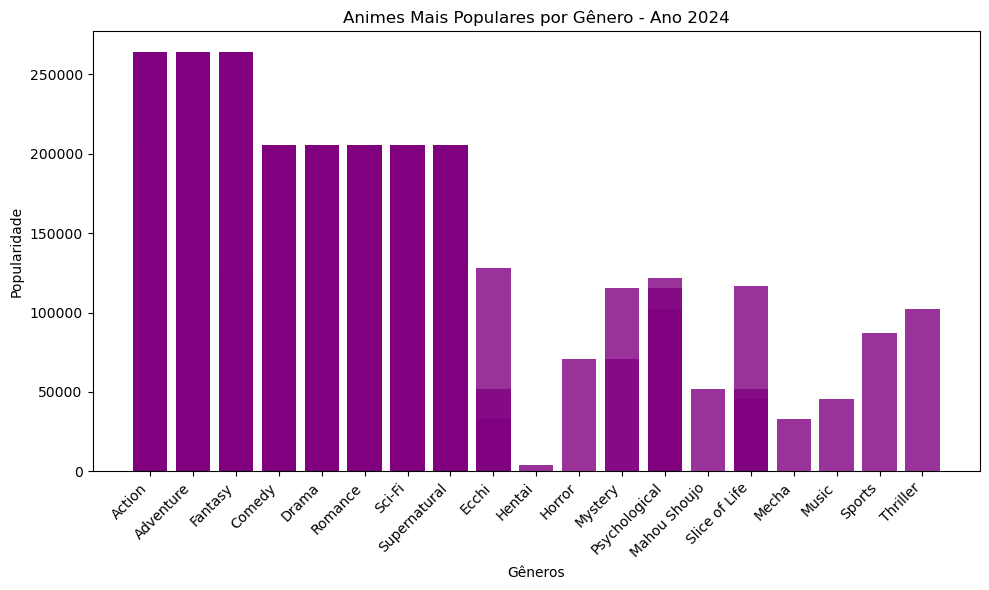

In [ ]:
yearly_data_2024 = most_popular_by_genre_year[most_popular_by_genre_year['Year'] == 2024]

plt.figure(figsize=(10, 6))
plt.bar(
    yearly_data_2024['Genres'], 
    yearly_data_2024['Popularity'], 
    color='purple', 
    alpha=0.8
)
plt.title('Animes Mais Populares por Gênero - Ano 2024')
plt.xlabel('Gêneros')
plt.ylabel('Popularidade')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()


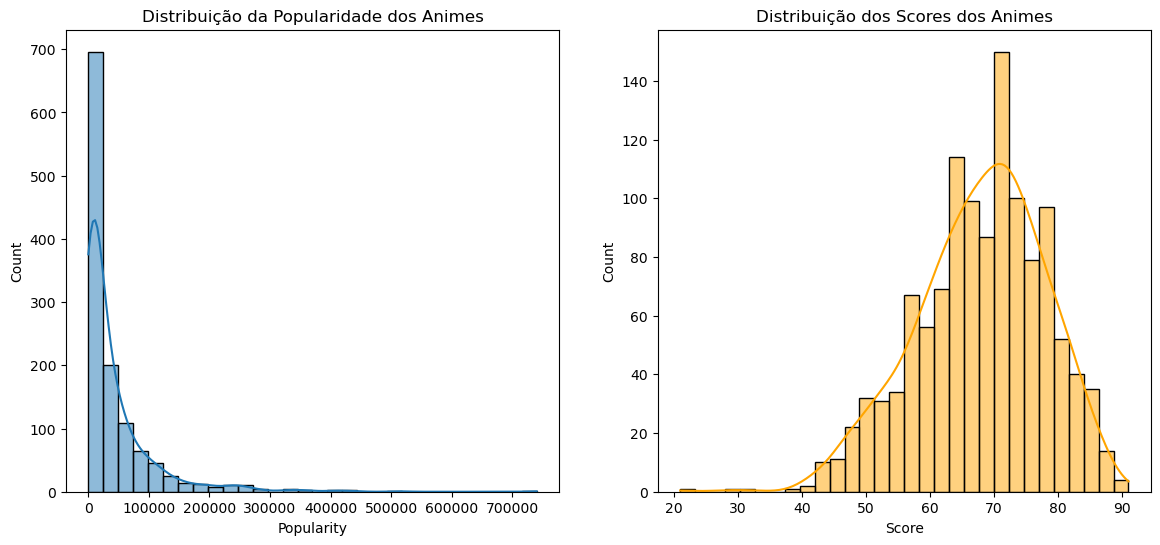

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(df_cleaned["Popularity"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribuição da Popularidade dos Animes")

sns.histplot(df_cleaned["Score"].dropna(), bins=30, kde=True, ax=axes[1], color="orange")
axes[1].set_title("Distribuição dos Scores dos Animes")

plt.show()

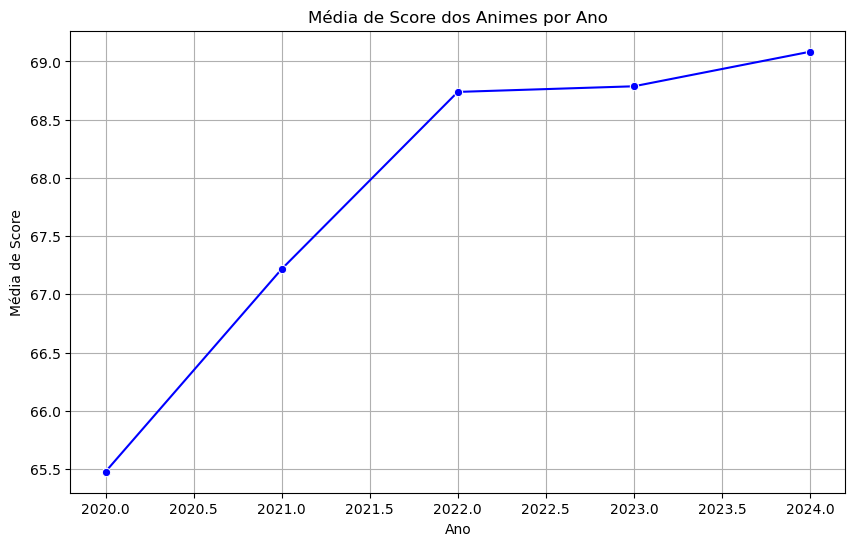

In [6]:
score_by_year = df_cleaned.groupby("Year")["Score"].mean()

plt.figure(figsize=(10, 6))
sns.lineplot(x=score_by_year.index, y=score_by_year.values, marker="o", color="blue")
plt.title("Média de Score dos Animes por Ano")
plt.xlabel("Ano")
plt.ylabel("Média de Score")
plt.grid(True)
plt.show()

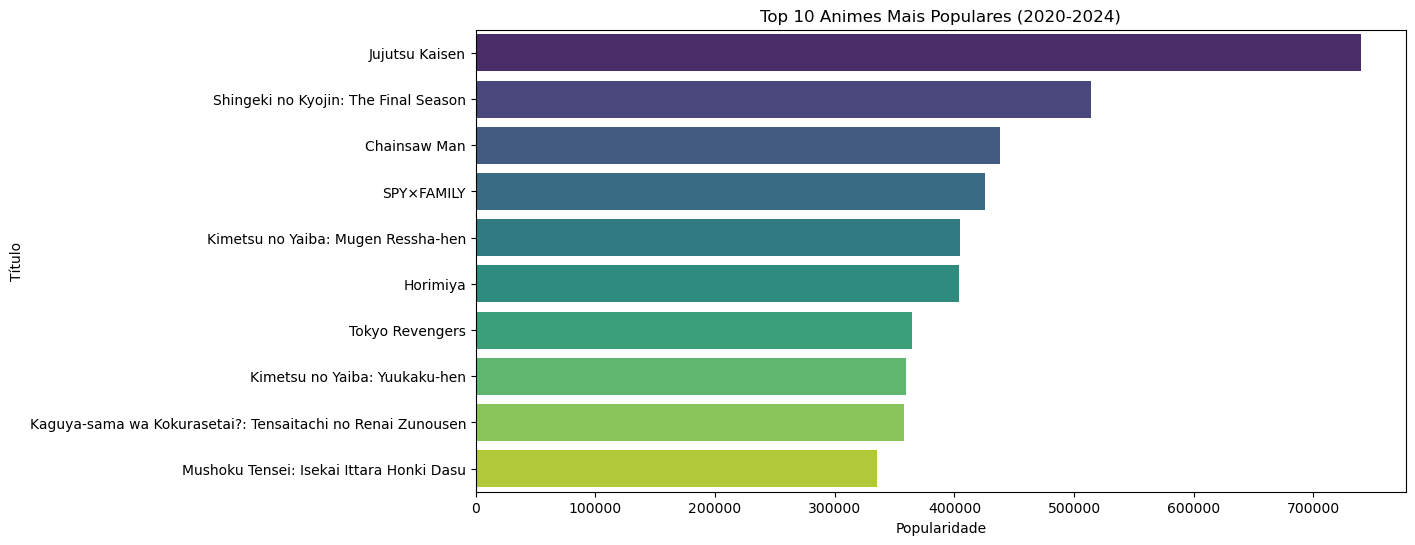

In [4]:
df_cleaned = df_cleaned.copy()

top_10_popular = df_cleaned.nlargest(10, "Popularity").copy()

plt.figure(figsize=(12, 6))
sns.barplot(x="Popularity", y="Title", data=top_10_popular, hue="Title", palette="viridis", legend=False)
plt.title("Top 10 Animes Mais Populares (2020-2024)")
plt.xlabel("Popularidade")
plt.ylabel("Título")
plt.show()

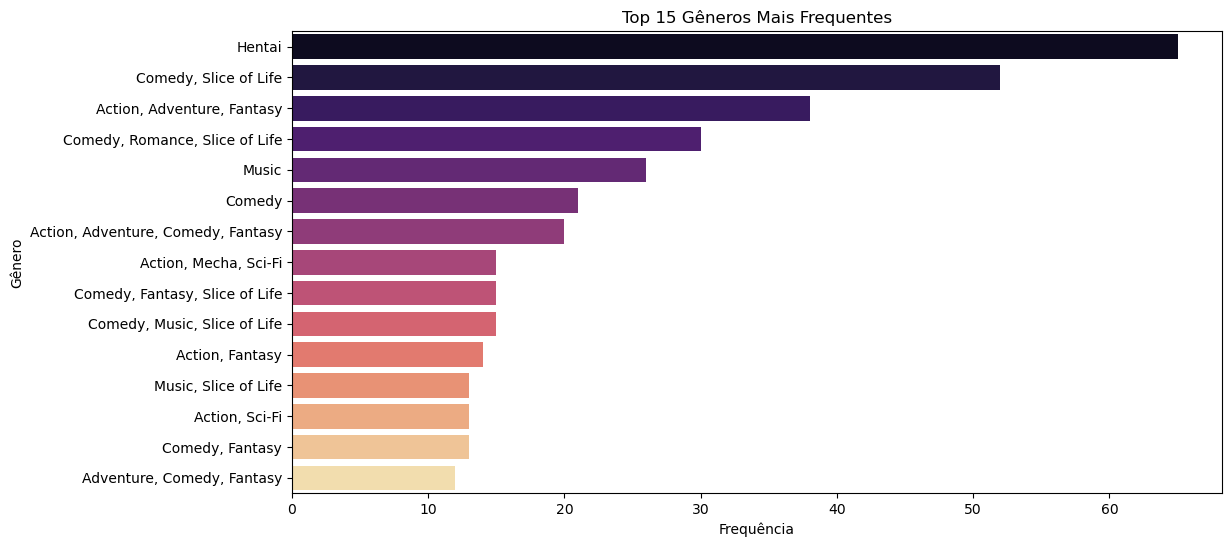

In [5]:
df_cleaned = df_cleaned.copy()

genre_counts = df_cleaned["Genres"].value_counts().head(15).copy()

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, hue=genre_counts.index, palette="magma", legend=False)
plt.title("Top 15 Gêneros Mais Frequentes")
plt.xlabel("Frequência")
plt.ylabel("Gênero")
plt.show()


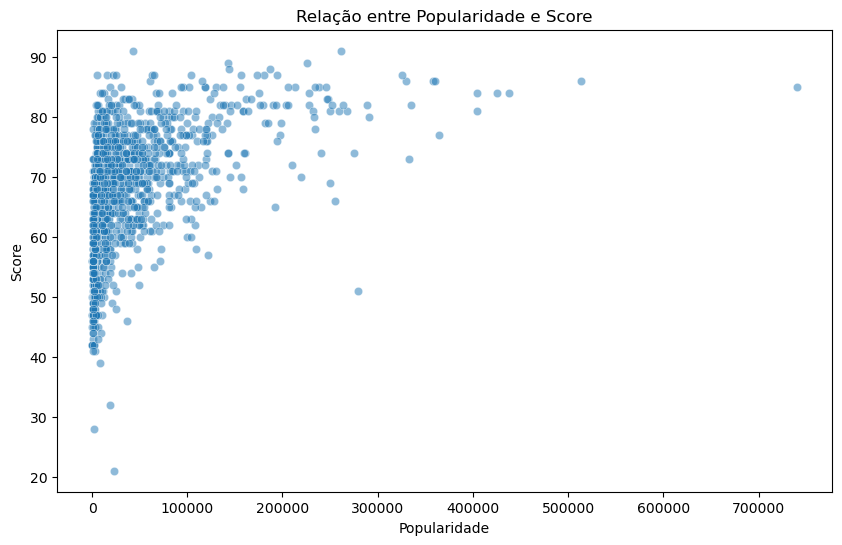

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Popularity", y="Score", data=df_cleaned, alpha=0.5)
plt.title("Relação entre Popularidade e Score")
plt.xlabel("Popularidade")
plt.ylabel("Score")
plt.show()

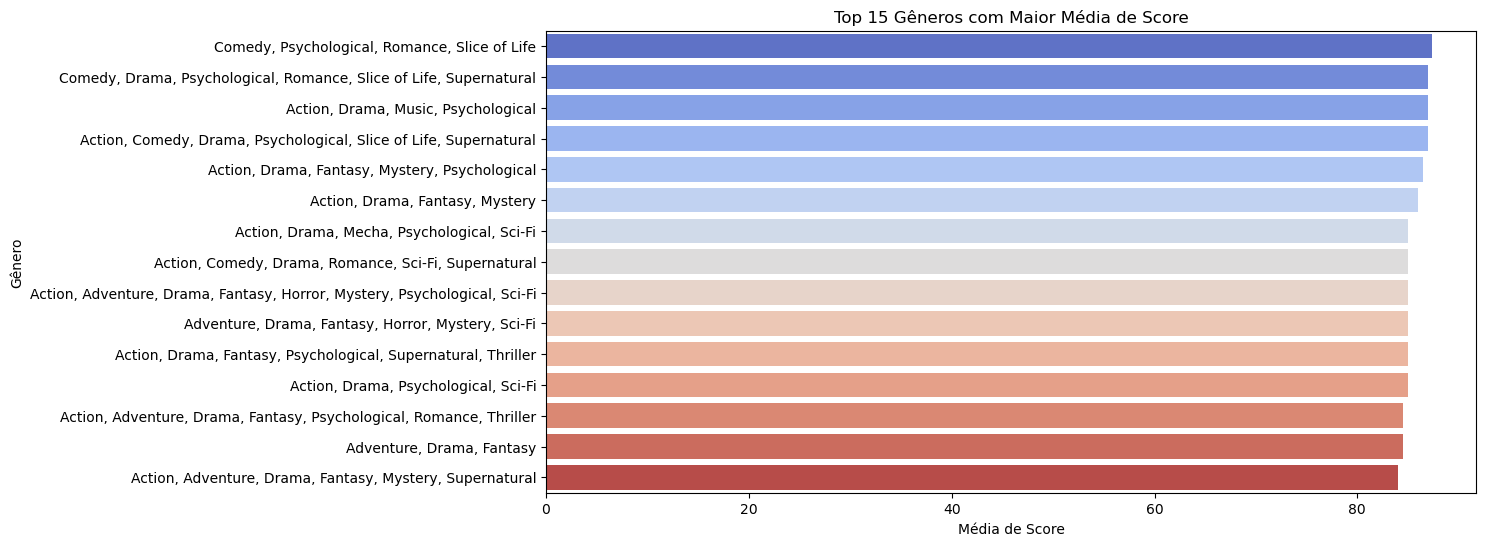

In [6]:
genre_score_mean = df_cleaned.groupby("Genres")["Score"].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_score_mean.values, y=genre_score_mean.index, hue=genre_score_mean.index, palette="coolwarm", legend=False)
plt.title("Top 15 Gêneros com Maior Média de Score")
plt.xlabel("Média de Score")
plt.ylabel("Gênero")
plt.show()

In [42]:
df_cleaned = df_cleaned.copy()
df_cleaned["Genres"] = df_cleaned["Genres"].fillna("")
df_cleaned["Genres_Combined"] = df_cleaned.groupby("Title")["Genres"].transform(lambda x: " ".join(x))
df_cleaned = df_cleaned.drop_duplicates(subset=["Title", "Genres_Combined"]).reset_index(drop=True)

tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(df_cleaned["Genres_Combined"])

num_clusters = 10
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df_cleaned["Cluster"] = kmeans.fit_predict(tfidf_matrix)

def find_closest_anime(title):
    matches = df_cleaned[df_cleaned["Title"].str.contains(title, case=False, na=False)]
    if not matches.empty:
        return matches.iloc[0]["Title"]
    return None

def recommend_by_cluster(anime_title, num_recommendations=5):
    anime_title = find_closest_anime(anime_title)
    
    if anime_title is None:
        return f"Anime '{anime_title}' não encontrado na base de dados."

    cluster_id = df_cleaned.loc[df_cleaned["Title"] == anime_title, "Cluster"].values[0]
    similar_animes = df_cleaned[df_cleaned["Cluster"] == cluster_id].sample(
        n=min(num_recommendations, len(df_cleaned[df_cleaned["Cluster"] == cluster_id])),
        random_state=42
    )

    return similar_animes["Title"].tolist()

example_anime = "Black Clover"
recommended_animes_by_cluster = recommend_by_cluster(example_anime, num_recommendations=10)

print(f"Animes similares a '{example_anime}':")
for anime in recommended_animes_by_cluster:
    print(f"- {anime}")

Animes similares a 'Black Clover':
- Maou-sama, Retry! R
- Kuramerukagari
- Cardfight!! Vanguard: will+Dress Season 3
- Arifureta Shokugyou de Sekai Saikyou 3rd season
- Shadowverse
- Goblin Slayer II
- Bye Bye, Earth
- Shenmue the Animation
- Saikyou Tank no Meikyuu Kouryaku: Tairyoku 9999 no Rare Skill-mochi Tank, Yuusha Party wo Tsuihou Sareru
- Kin no Kuni Mizu no Kuni
